In [9]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("Alpha_Spectrum.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
Alpha_Spectrum.ipynb started: Tue, 12 May 2026 14:46:16
INFO: SETUP COMPLETE (1796.88 ms)
---------------------------------------


In [149]:
decay_data = {'238-Pu':{
    'half-life': 87.7,
    'decays_into': '234-U',
    'alphas': {
        'A_0,0': [5499.03,0.7104,4],
        'A_0,1': [5456.3, 0.2885,2]
    }},
        '239-Pu':{
    'half-life': 24110,
    'decays_into': '235-U',
    'alphas': {
        'A_0,1': [5156.59,0.7079,3],
        'A_0,2': [5143.82,0.1714,2],
        'A_0,4': [5105.81,0.1187,0]
    }},
        '240-Pu':{
    'half-life': 6561,
    'decays_into': '236-U',
    'alphas': {
        'A_0,0': [5168.13,0.7274,4],
        'A_0,1': [5123.6,0.2716,1]
    }},
        '241-Am':{
    'half-life': 432.6,
    'decays_into': '237-Np',
    'alphas': {
        'A_0,2': [5485.56,0.8445,3],
        'A_0,4': [5442.86,0.1323,1],
        'A_0,6': [5388.25,0.0166,0]
    }},
        '244-Cm':{
    'half-life': 18.11,
    'decays_into': '240-Pu',
    'alphas': {
        'A_0,0': [5807.77,0.767,1],
        'A_0,1': [5762.65,0.233,0]
    }}
        }

In [156]:
def alpha_spectrum(DW):
    plt.figure(figsize=(10,4), dpi=300)
    DET_WIDTH = DW #keV

    j = 0
    total_spectrum = {}
    x_lin_total = np.linspace(5000,5900,2500)

    for isotope in decay_data.keys():
        alphas = decay_data[isotope]['alphas']
        for channel in alphas.keys():
            ch = channel[1:]
            
            if ch[-1] == '0':
                ls = '-'
            elif ch[-1] == '1':
                ls = 'dashdot'
            elif ch[-1] == '2':
                ls = ':'
            elif ch[-1] == '4':
                ls = '--'
            elif ch[-1] == '6':
                ls = '-.'
            
            x_lin = np.linspace(alphas[channel][0]-3*DET_WIDTH, alphas[channel][0]+3*DET_WIDTH, 500)
            
            fit = gauss_func([alphas[channel][1],alphas[channel][0], DET_WIDTH],x_lin)
            
            total_spectrum[f'{j}_{ch}'] = gauss_func([alphas[channel][1],alphas[channel][0], DET_WIDTH],x_lin_total)
            
            if j == 2:
                plt.plot(x_lin, fit, lw=0.75, ls=ls, color=color_schemes['c_complementary'][j+4], label=f'{isotope} - ' + r'$\alpha$' + f'{ch}', zorder=2)
                plt.vlines(alphas[channel][0], alphas[channel][1], 1 + alphas[channel][2]* 0.08, color=color_schemes['c_complementary'][j+4], lw=0.5)
                # plt.text(alphas[channel][0], alphas[channel][1]+0.7 + 0.02, s = f'{alphas[channel][0]} keV', color='black', rotation=0, horizontalalignment='right', verticalalignment='bottom')
            else:
                plt.plot(x_lin, fit, lw=0.75, ls=ls, color=color_schemes['c_complementary'][j], label=f'{isotope} - ' + r'$\alpha$' + f'{ch}', zorder=2)
                plt.vlines(alphas[channel][0], alphas[channel][1], 1 + alphas[channel][2]* 0.08, color=color_schemes['c_complementary'][j], lw=0.5)
            plt.text(alphas[channel][0], 1 + alphas[channel][2]* 0.08, s = f'{alphas[channel][0]} keV', color='black', rotation=0, horizontalalignment='right', verticalalignment='bottom')#, bbox={'facecolor': 'white', 'alpha': 1, 'pad': 1, 'edgecolor':'white'})
            
        j += 1
        
    # stacked = np.vstack(list(total_spectrum.values()))
    # envelope = np.sum(stacked, axis=0)   
    # plt.plot(x_lin_total, envelope, lw=0.75, ls='-', color='black', label=f'total spectrum', zorder=2)
    plt.xticks(np.linspace(5000,6100,12))

    plt.ylim(0,1.4)
    plt.title(r'\texttt{Harwell} source alpha spectrum - FWHM = '+ f'{DET_WIDTH} keV')
    plt.grid()
    plt.legend()
    plt.savefig(f'HarwellSource_Alpha_spectrum_{DET_WIDTH}keV.png', transparent=False, dpi=300)
    plt.savefig(f'HarwellSource_Alpha_spectrum_{DET_WIDTH}keV.pdf', transparent=False, dpi=300)
    

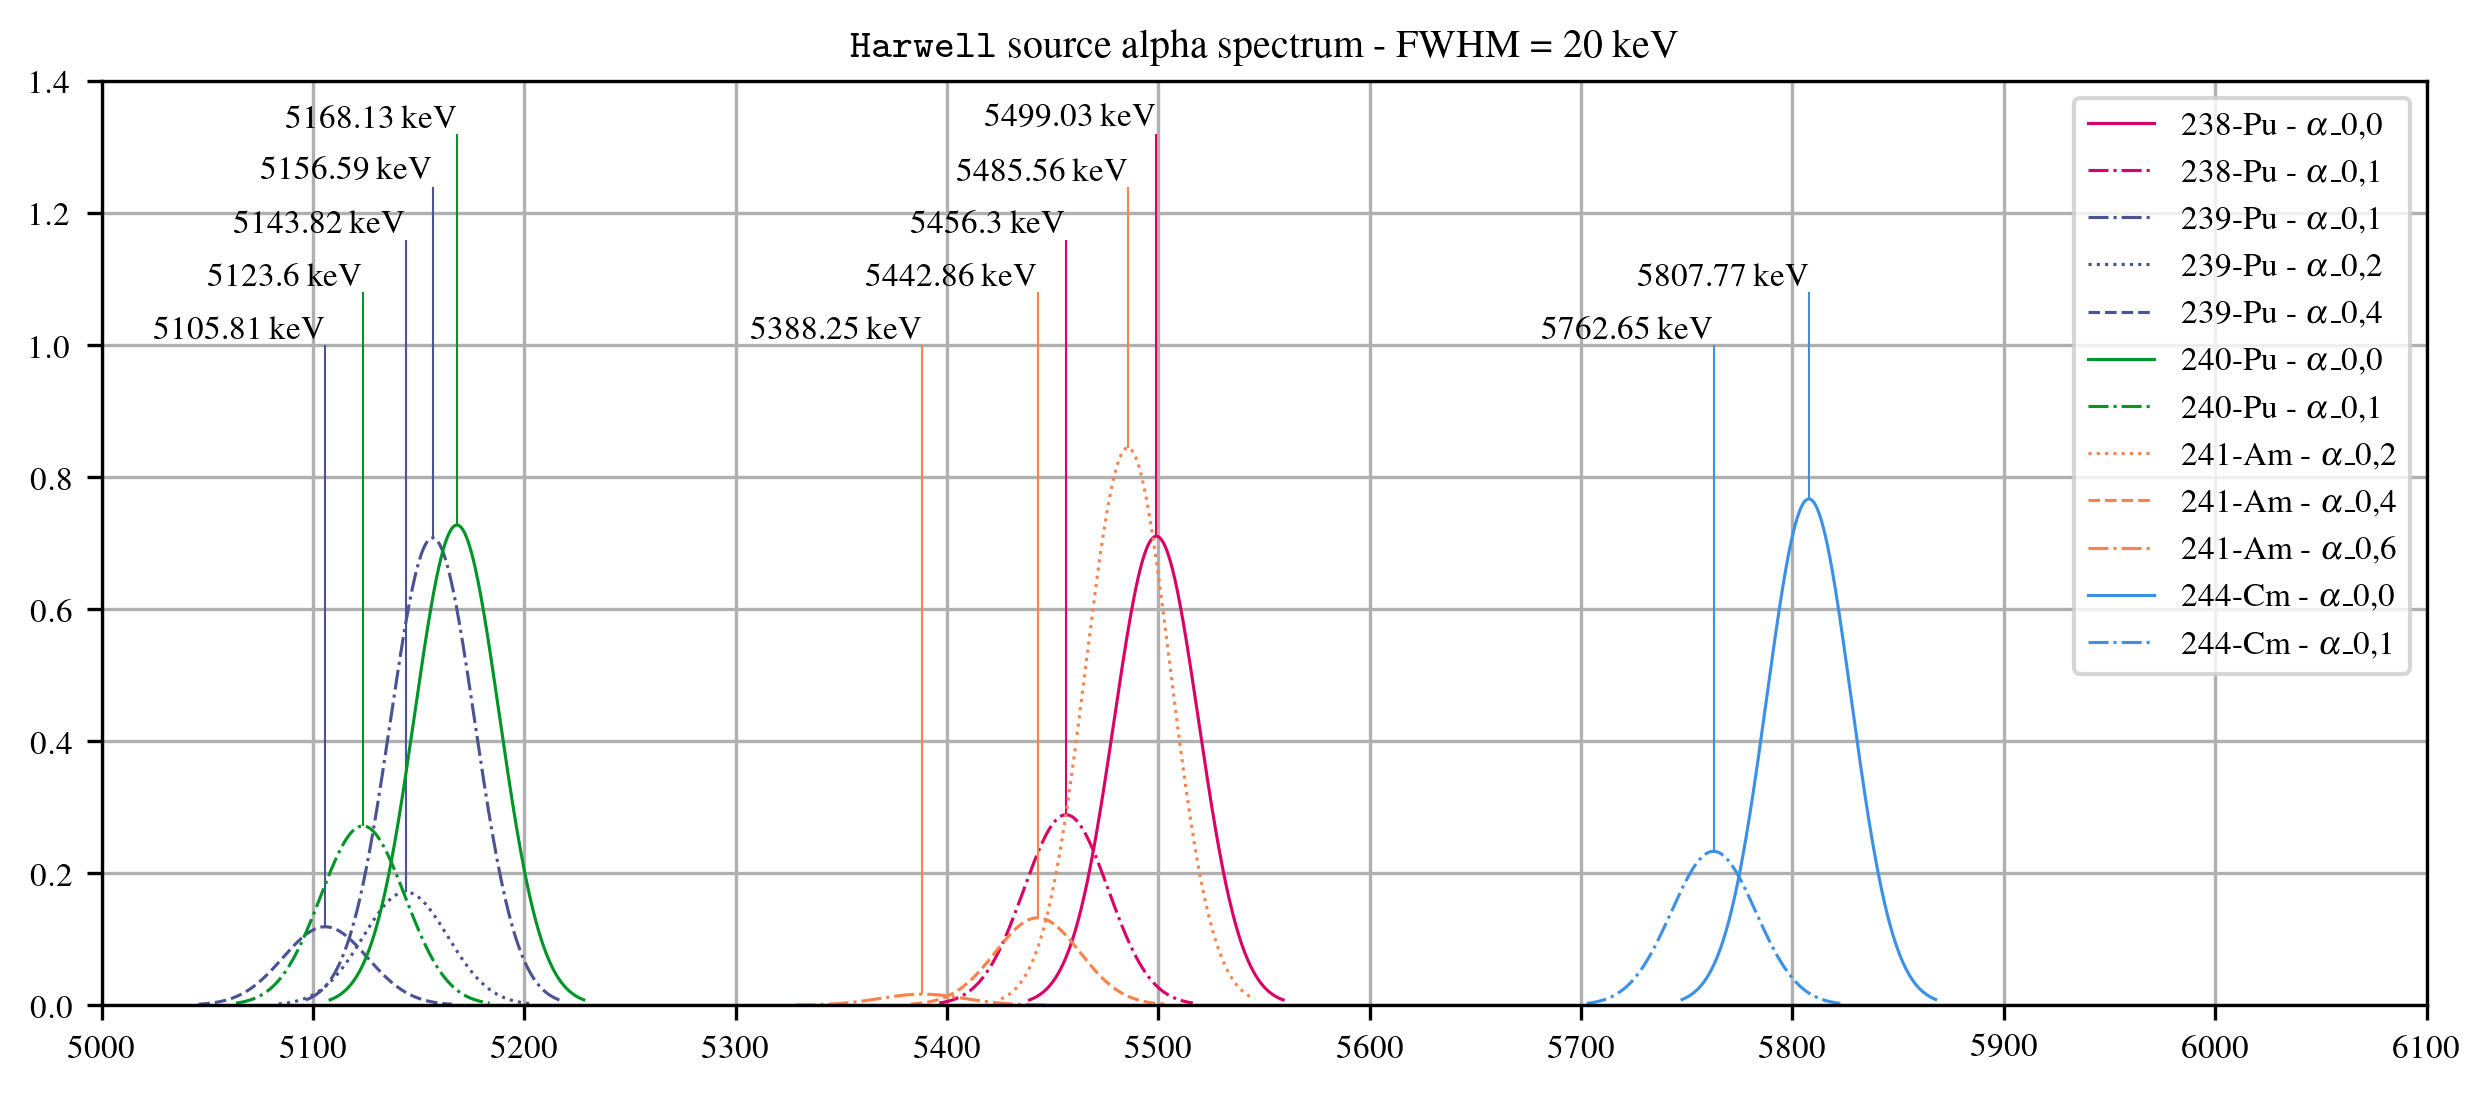

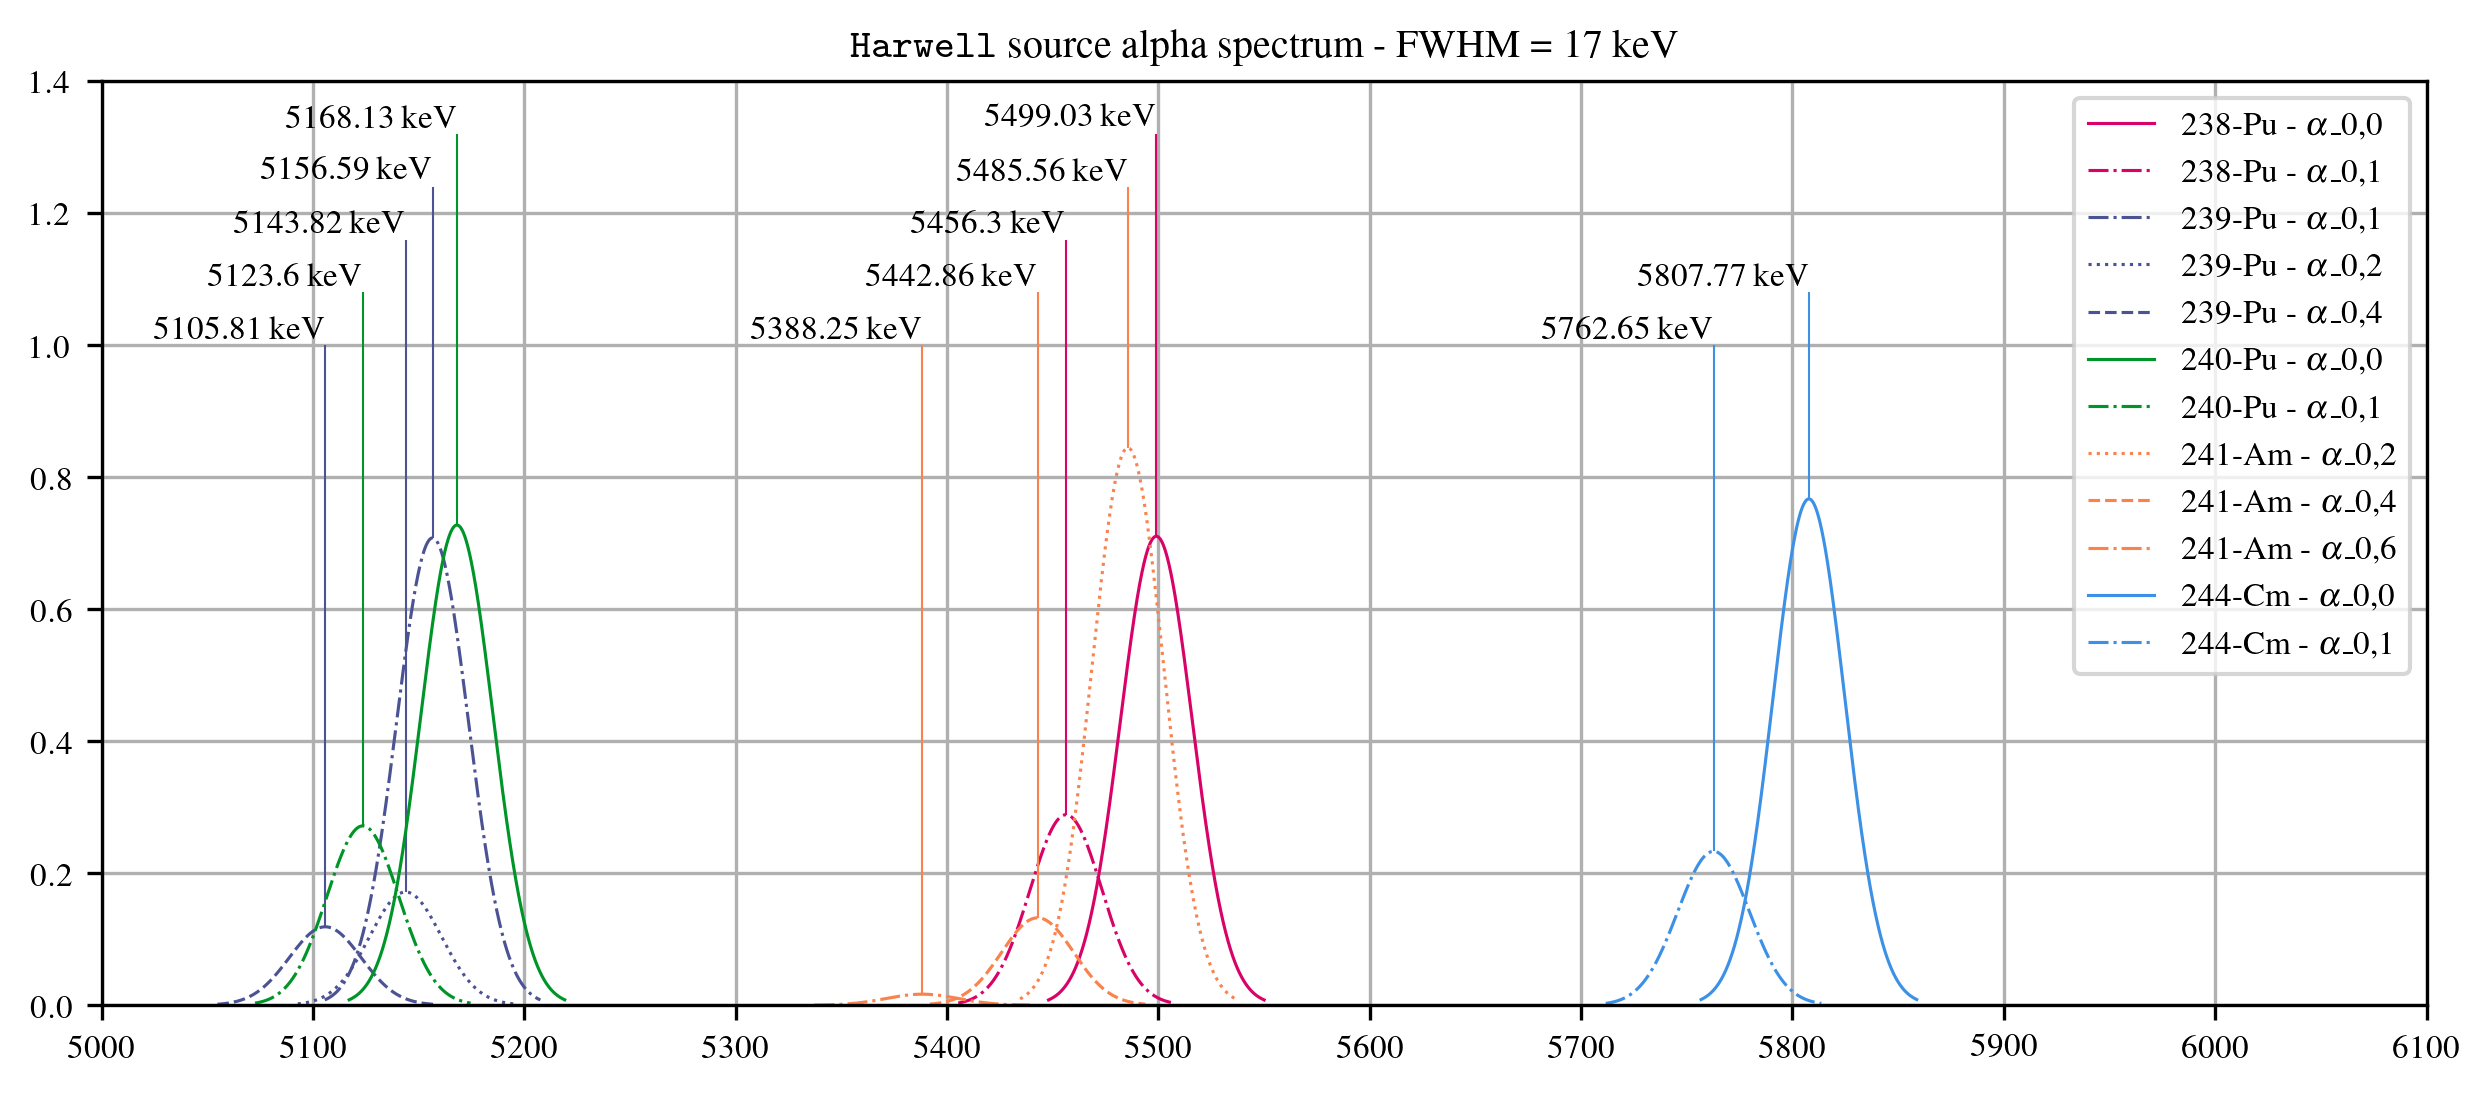

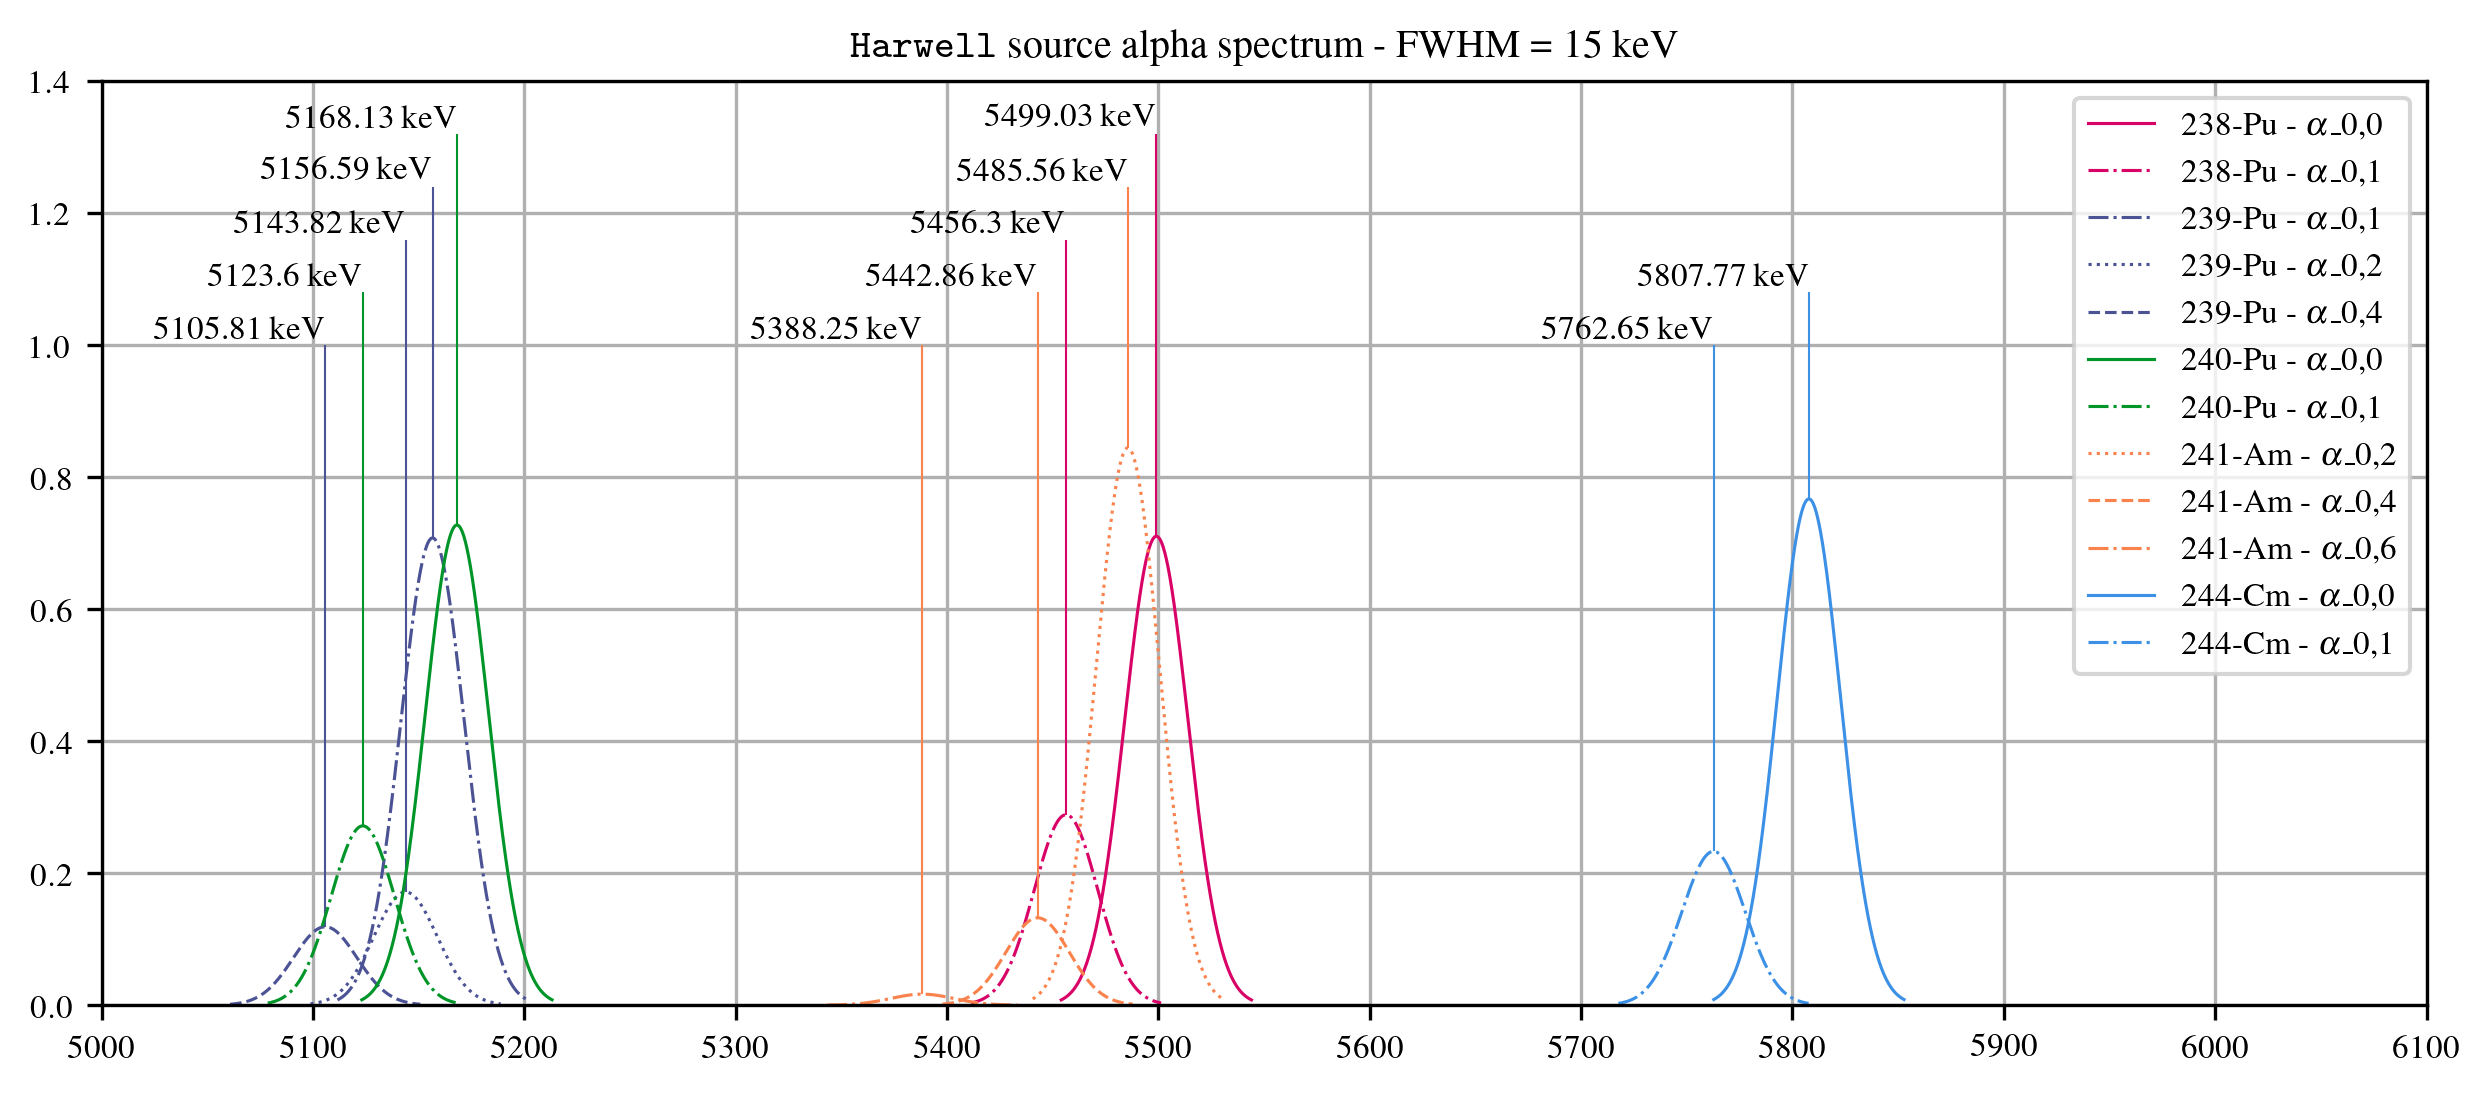

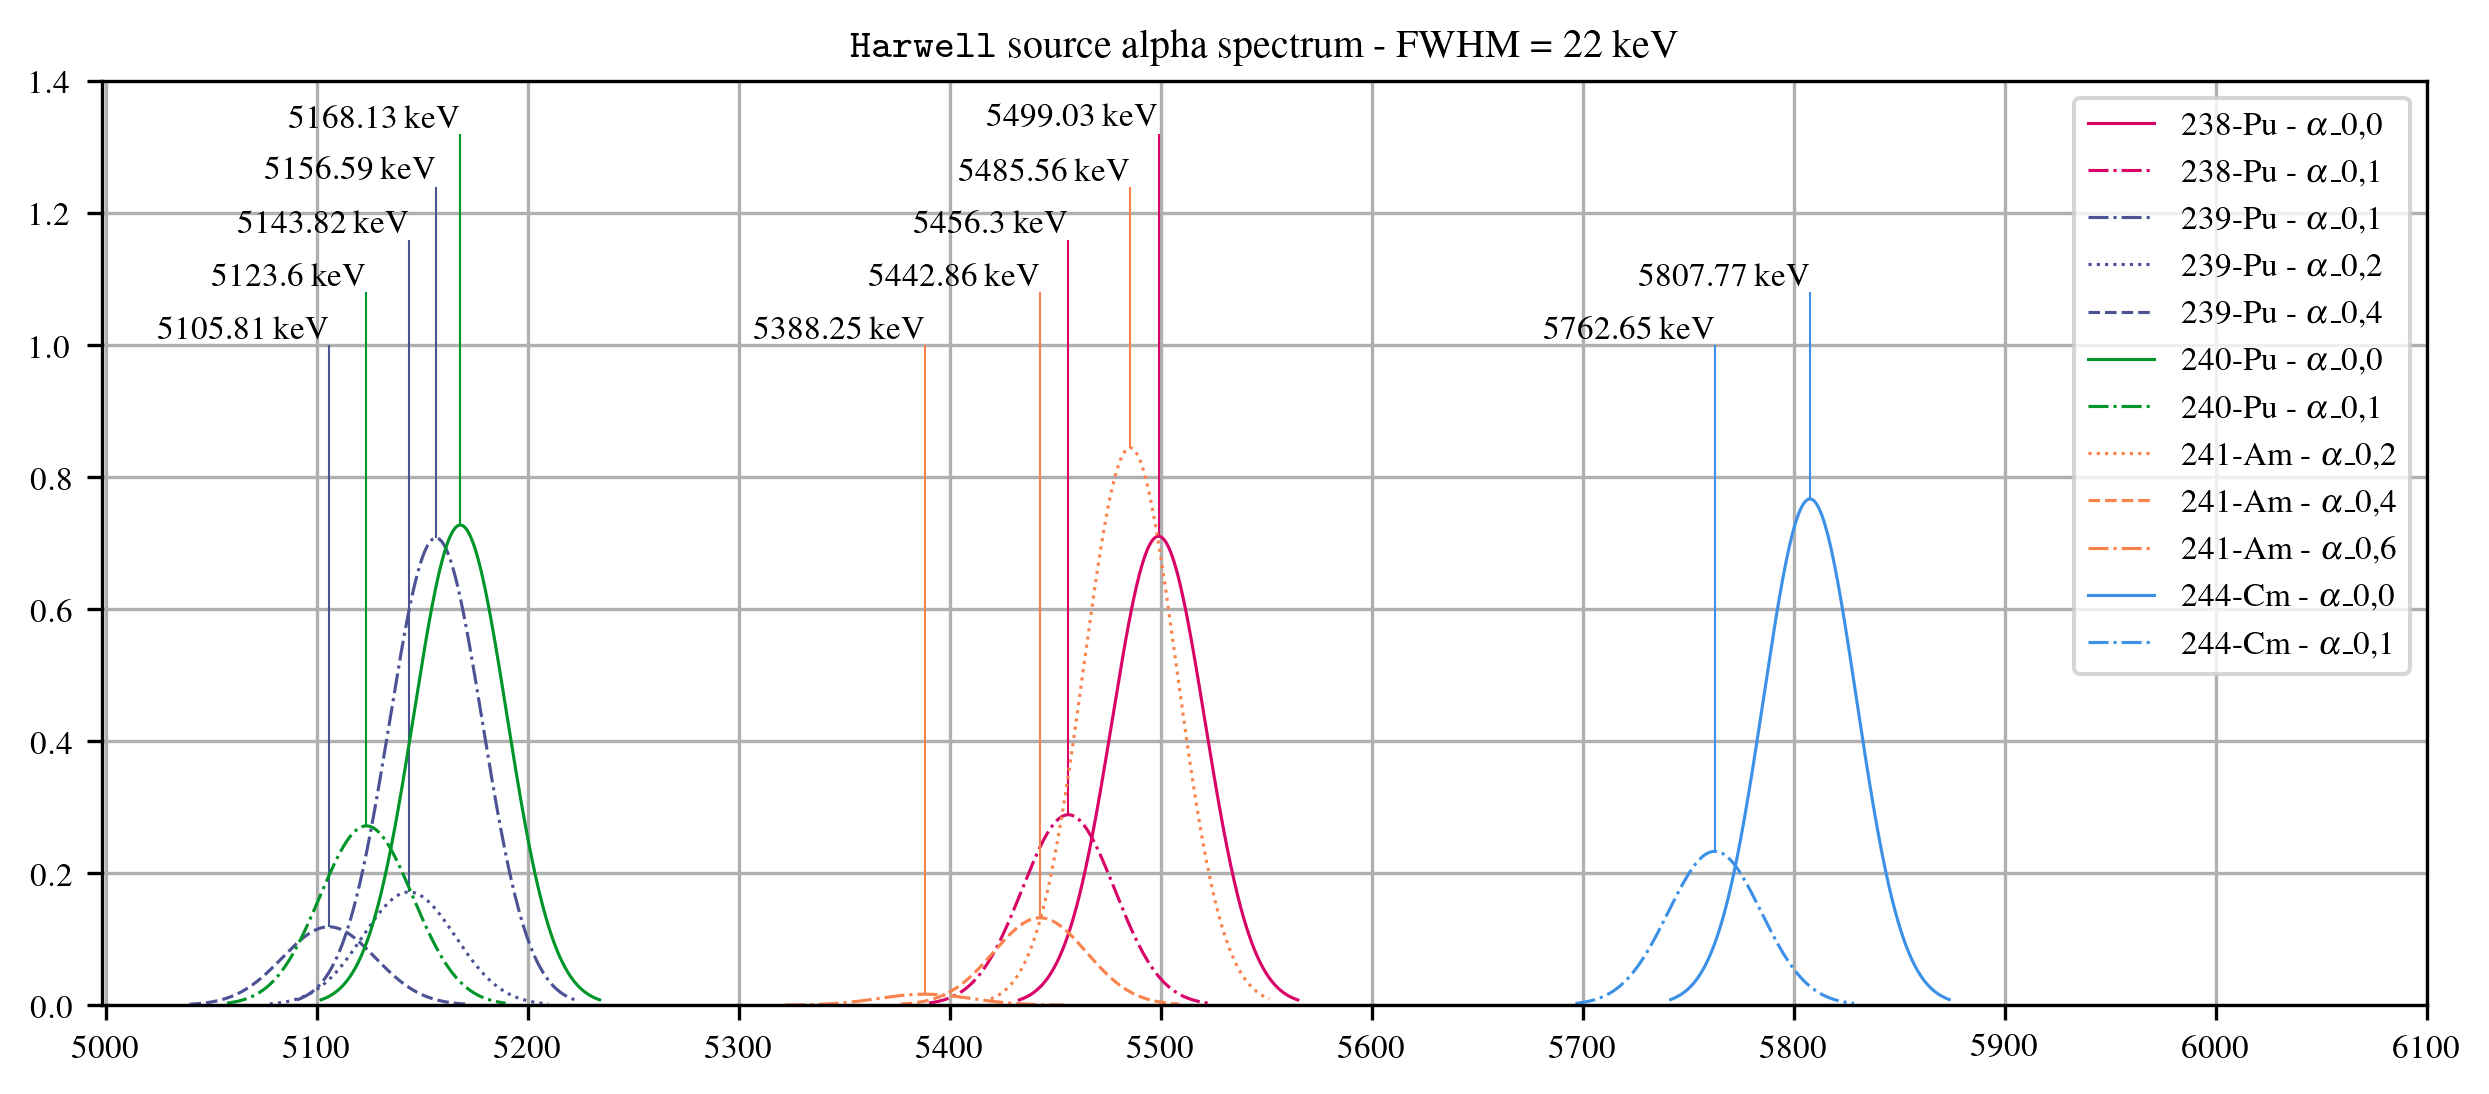

In [158]:
alpha_spectrum(DW=20)
alpha_spectrum(DW=17)
alpha_spectrum(DW=15)
alpha_spectrum(DW=22)